# Бизнес-анализ и финальная оценка модели

Цель этапа:

1. Проверить качество вероятностей CatBoost.
2. Выбрать порог классификации на validation-выборке.
3. Учесть различную стоимость ошибок.
4. Один раз оценить выбранное решение на test-выборке.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
validation_data = pd.read_csv("/Users/ilyaklimasin/credit-risk-scoring/reports/validation_predictions.csv")
test_data = pd.read_csv("/Users/ilyaklimasin/credit-risk-scoring/reports/test_predictions.csv")

y_valid = validation_data["target"]
valid_probabilities = validation_data["probability"]
y_test = test_data["target"]
test_probabilities = test_data["probability"]
print("Validation: ", validation_data.shape)
print("Test: ", test_data.shape)

valid_brier = brier_score_loss(y_valid, valid_probabilities)
print(f"Validation Brier score: {valid_brier:.4f}")

Validation:  (61502, 2)
Test:  (61503, 2)
Validation Brier score: 0.0676


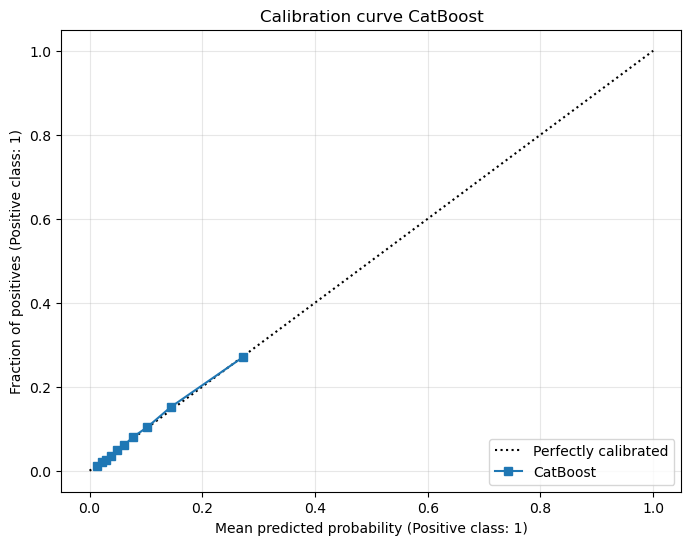

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(y_valid, valid_probabilities, n_bins=10, strategy="quantile", ax=ax, name="CatBoost")
plt.title("Calibration curve CatBoost")
plt.grid(alpha=0.3)
plt.show()

Как читать график: ближе к диагонали, значит вероятности точнее; выше диагонали, значит модель недооценивает риск; ниже диагонали, значит модель переоценивает риск. Производим анализ модели.

In [8]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
thresholds_results = []
for threshold in thresholds:
    prediction = (valid_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, prediction).ravel()
    thresholds_results.append({
        "threshold": threshold,
        "precision": precision_score(y_valid, prediction, zero_division=0),
        "recall": recall_score(y_valid, prediction, zero_division=0),
        "f1": f1_score(y_valid, prediction, zero_division=0),
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "true_negative": tn,
    })

thresholds_results = pd.DataFrame(thresholds_results)
thresholds_results.round(4)

,threshold,precision,recall,f1,false_positive,false_negative,true_positive,true_negative
0,0.05,0.1284,0.8481,0.2230,28591,754,4211,27946
1,0.10,0.1896,0.5966,0.2877,12662,2003,2962,43875
2,0.15,0.2427,0.4099,0.3048,6351,2930,2035,50186
3,0.20,0.2944,0.2870,0.2906,3416,3540,1425,53121
4,0.25,0.3510,0.2012,0.2558,1847,3966,999,54690
5,0.30,0.4020,0.1376,0.2050,1016,4282,683,55521


In [9]:
FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 5

thresholds_results["business_cost"] = thresholds_results["false_positive"]*FALSE_POSITIVE_COST + thresholds_results["false_negative"]*FALSE_NEGATIVE_COST
thresholds_results.sort_values("business_cost").round(4)

,threshold,precision,recall,f1,false_positive,false_negative,true_positive,true_negative,business_cost
2,0.15,0.2427,0.4099,0.3048,6351,2930,2035,50186,21001
3,0.20,0.2944,0.2870,0.2906,3416,3540,1425,53121,21116
4,0.25,0.3510,0.2012,0.2558,1847,3966,999,54690,21677
5,0.30,0.4020,0.1376,0.2050,1016,4282,683,55521,22426
1,0.10,0.1896,0.5966,0.2877,12662,2003,2962,43875,22677
0,0.05,0.1284,0.8481,0.2230,28591,754,4211,27946,32361


In [11]:
best_row = thresholds_results.loc[thresholds_results["business_cost"].idxmin()]
best_threshold = best_row["threshold"]

print(f"Choose bound: {best_threshold:.2f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall: {best_row['recall']:.4f}")
print(f"F1: {best_row['f1']:.4f}")
print(f"Business cost: {best_row['business_cost']:.0f}")

Choose bound: 0.15
Precision: 0.2427
Recall: 0.4099
F1: 0.3048
Business cost: 21001


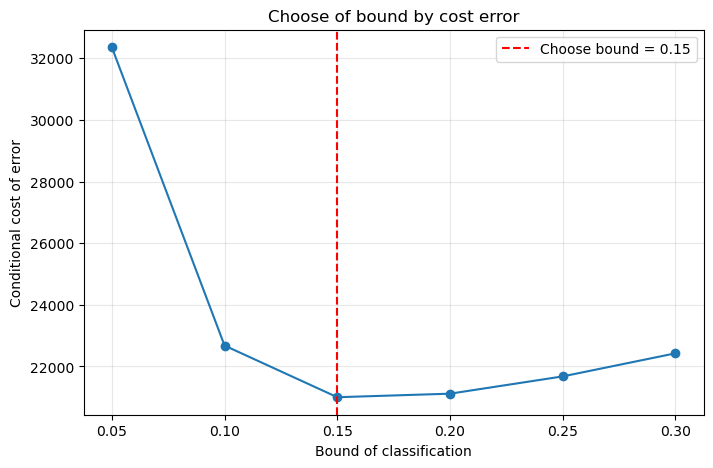

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds_results["threshold"], thresholds_results["business_cost"], marker="o")

plt.axvline(best_threshold, linestyle="--", color="red", label=f"Choose bound = {best_threshold:.2f}")
plt.xlabel("Bound of classification")
plt.ylabel("Conditional cost of error")
plt.title("Choose of bound by cost error")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
test_class_prediction = (test_probabilities >= best_threshold).astype(int)

test_metrics = {
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "pr_auc": average_precision_score(y_test, test_probabilities),
    "brier_score": brier_score_loss(y_test, test_probabilities),
    "precision": precision_score(y_test, test_class_prediction, zero_division=0),
    "recall": recall_score(y_test, test_class_prediction, zero_division=0),
    "f1": f1_score(y_test, test_class_prediction, zero_division=0)
}
pd.Series(test_metrics).round(4)

roc_auc        0.7662
pr_auc         0.2518
brier_score    0.0674
precision      0.2518
recall         0.4213
f1             0.3152
dtype: float64

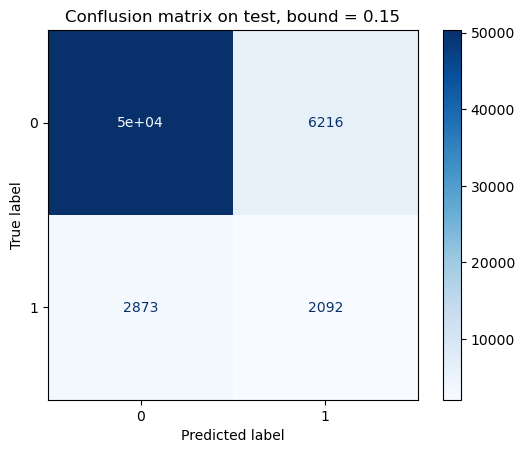

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, test_class_prediction, cmap="Blues")
plt.title(f"Conflusion matrix on test, bound = {best_threshold:.2f}")
plt.show()

In [17]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_class_prediction
).ravel()

test_business_cost = (
    fp * FALSE_POSITIVE_COST
    +
    fn * FALSE_NEGATIVE_COST
)

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)
print("Test business cost:", test_business_cost)

True Negative: 50322
False Positive: 6216
False Negative: 2873
True Positive: 2092
Test business cost: 20581


## Выводы четвёртого этапа

1. Качество вероятностных прогнозов CatBoost было проверено с помощью калибровочной кривой и Brier score.

2. На validation-выборке были рассмотрены пороги классификации от 0.05 до 0.30.

3. При выборе порога учитывалась различная стоимость ошибок:

   - стоимость False Positive принята равной 1 условной единице;
   - стоимость False Negative принята равной 5 условным единицам.

4. Минимальная условная стоимость ошибок на validation-выборке достигнута при пороге **[вставить `best_threshold`]**.

5. При выбранном пороге на test-выборке получены следующие результаты:

   - ROC-AUC — **0.7662**;
   - PR-AUC — **0.2518**;
   - Brier score — **0.0674**;
   - Precision — **0.2518**;
   - Recall — **0.4213**;
   - F1-score — **0.3152**.

6. На test-выборке модель:

   - правильно определила **2 092** дефолтных клиента;
   - пропустила **2 873** дефолтных клиента;
   - ошибочно отнесла **6 216** надёжных клиентов к рискованным;
   - правильно определила **50 322** надёжных клиента.

7. При выбранном пороге модель выявила около **42.1%** клиентов, допустивших дефолт. Среди клиентов, отнесённых моделью к рискованным, около **25.2%** действительно допустили дефолт.

8. Итоговая условная стоимость ошибок на test-выборке составила **20 581 условную единицу**:

   ```text
   6 216 × 1 + 2 873 × 5 = 20 581
   ```

9. Порог был выбран только по validation-выборке. Test-выборка использовалась один раз для финальной оценки и не применялась для дальнейшей настройки модели.

10. Значения test-метрик близки к результатам на validation-выборке. ROC-AUC увеличился с **0.7603** до **0.7662**, PR-AUC — с **0.2484** до **0.2518**, а Brier score уменьшился с **0.0676** до **0.0674**. Это указывает на стабильное качество модели на отложенных данных.

11. Использованные стоимости ошибок являются учебным предположением. В реальной задаче они должны определяться с учётом размера кредита, ожидаемой прибыли, потерь при дефолте и политики риск-менеджмента.

12. CatBoost был выбран финальной моделью, поскольку превзошёл Dummy baseline и Logistic Regression по ROC-AUC, PR-AUC и Brier score.